In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [33]:
df = pd.read_csv('data/대구_우울증&불면증_환자수_전월.csv', encoding='utf-8')

In [34]:
df

,진료년월,우울증_환자수,불면증_환자수,대구_열대야일수
0,2020년 05월,17805,10241,0
1,2020년 06월,18226,10156,0
2,2020년 07월,18654,10285,1
3,2020년 08월,18353,9997,15
4,2020년 09월,18951,10530,0
...,...,...,...,...
59,2025년 04월,24287,13434,0
60,2025년 05월,24298,13159,0
61,2025년 06월,23781,12897,3
62,2025년 07월,24120,13100,8


In [35]:
df1 = pd.read_csv('data/insomnia_daegu_clean2.csv', encoding='utf-8')

In [ ]:
df1.info()
df1['날짜'] = pd.to_datetime(df1['날짜'])
df['']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   날짜       64 non-null     object
 1   불면증_환자수  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       64 non-null     datetime64[ns]
 1   불면증_환자수  64 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 1.1 KB


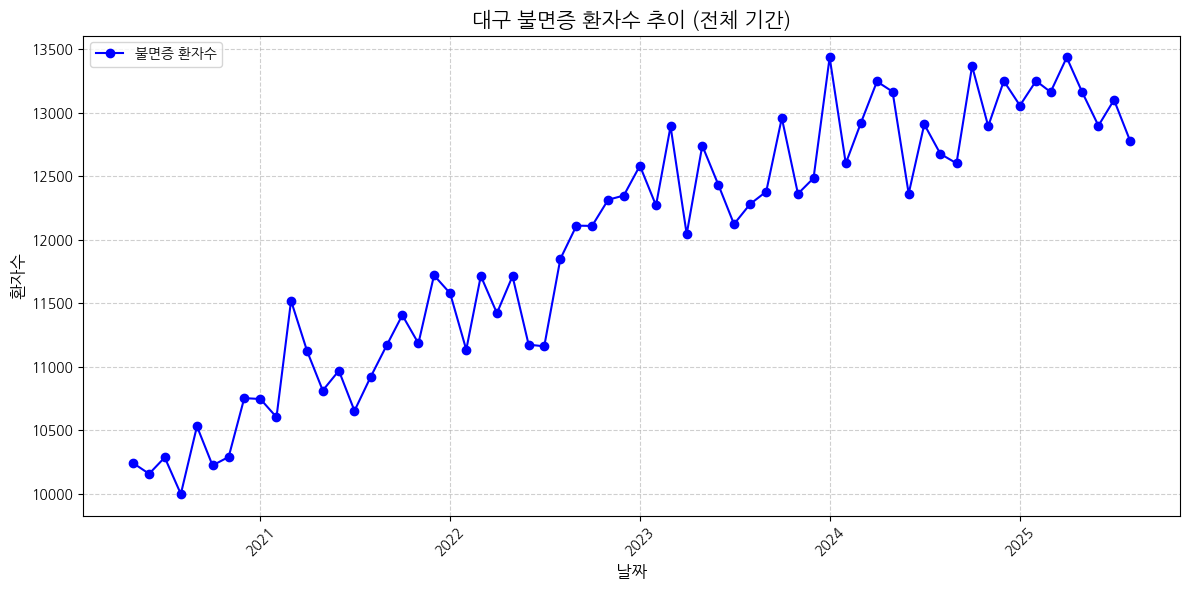

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df1['날짜'], df1['불면증_환자수'], marker='o', color='b', label='불면증 환자수')
plt.title('대구 불면증 환자수 추이 (전체 기간)', fontsize=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('환자수', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()
# 대구 불면증 환자수 추이를 볼 수 있게 한다.

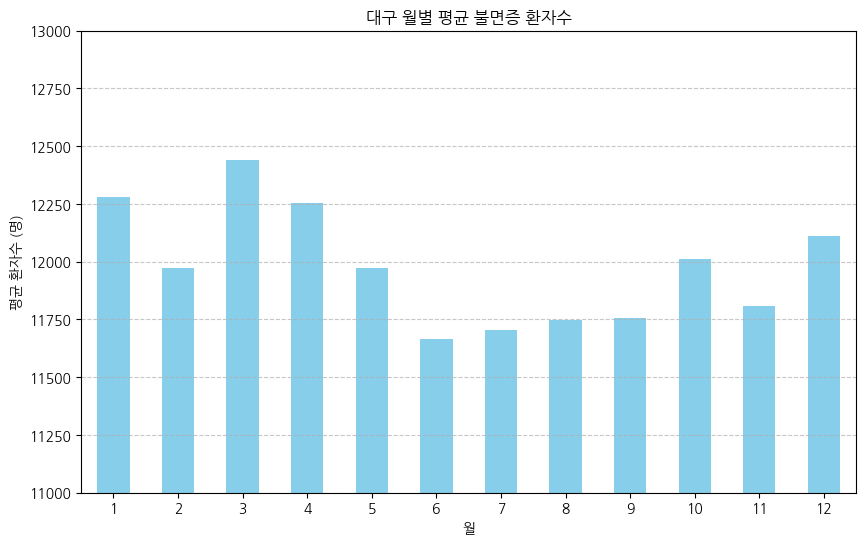

In [51]:
# 이제 월별 평균을 낸다.
df1['월'] = df1['날짜'].dt.month

#여기서 월별로 그룹으로 만들고 평균을 계산한다.
monthly_avg = df1.groupby('월')['불면증_환자수'].mean().round(1)
plt.figure(figsize=(10, 6))
monthly_avg.plot(kind='bar', color='skyblue')
plt.ylim(11000, 13000) #이거로 구간을 정리할 수 있음
plt.title('대구 월별 평균 불면증 환자수')
plt.xlabel('월')
plt.ylabel('평균 환자수 (명)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [44]:
df['진료년월'] = pd.to_datetime(df['진료년월'], format='%Y년 %m월')
print(df.head())
print(df.info())

        진료년월  우울증_환자수  불면증_환자수  대구_열대야일수
0 2020-05-01    17805    10241         0
1 2020-06-01    18226    10156         0
2 2020-07-01    18654    10285         1
3 2020-08-01    18353     9997        15
4 2020-09-01    18951    10530         0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   진료년월      64 non-null     datetime64[ns]
 1   우울증_환자수   64 non-null     int64         
 2   불면증_환자수   64 non-null     int64         
 3   대구_열대야일수  64 non-null     int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 2.1 KB
None


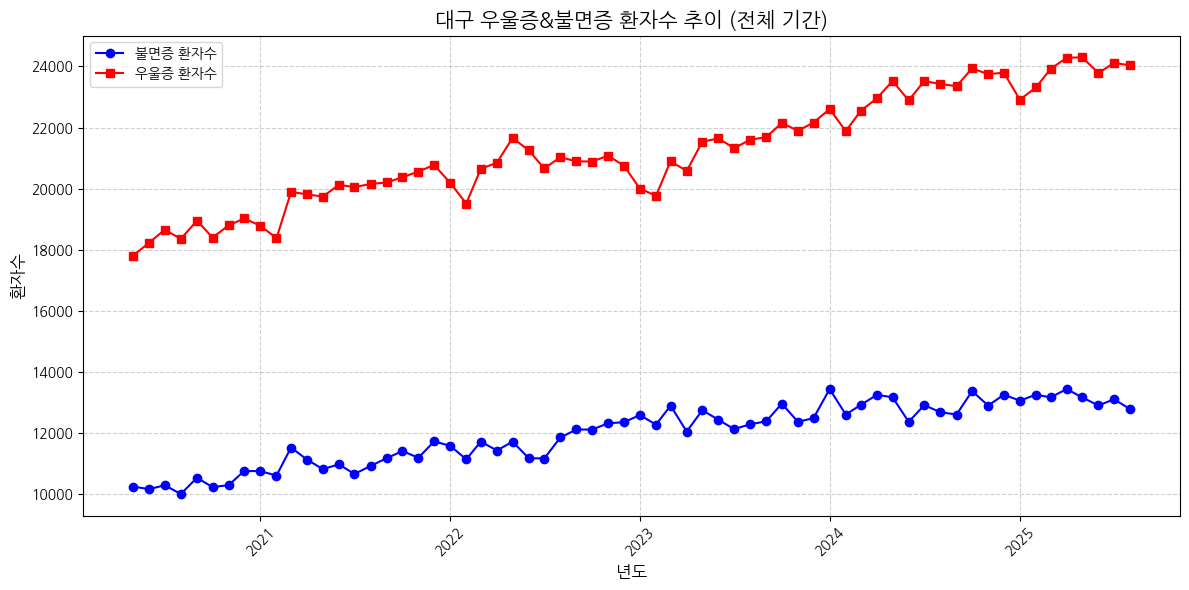

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df['진료년월'], df['불면증_환자수'], marker='o', color='b', label='불면증 환자수')
plt.plot(df['진료년월'], df['우울증_환자수'], marker='s', color='r', label='우울증 환자수')
plt.title('대구 우울증&불면증 환자수 추이 (전체 기간)', fontsize=15)
plt.xlabel('년도', fontsize=12)
plt.ylabel('환자수', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()
# 대구 불면증과 우울증 환자수 추이를 볼 수 있게 한다.

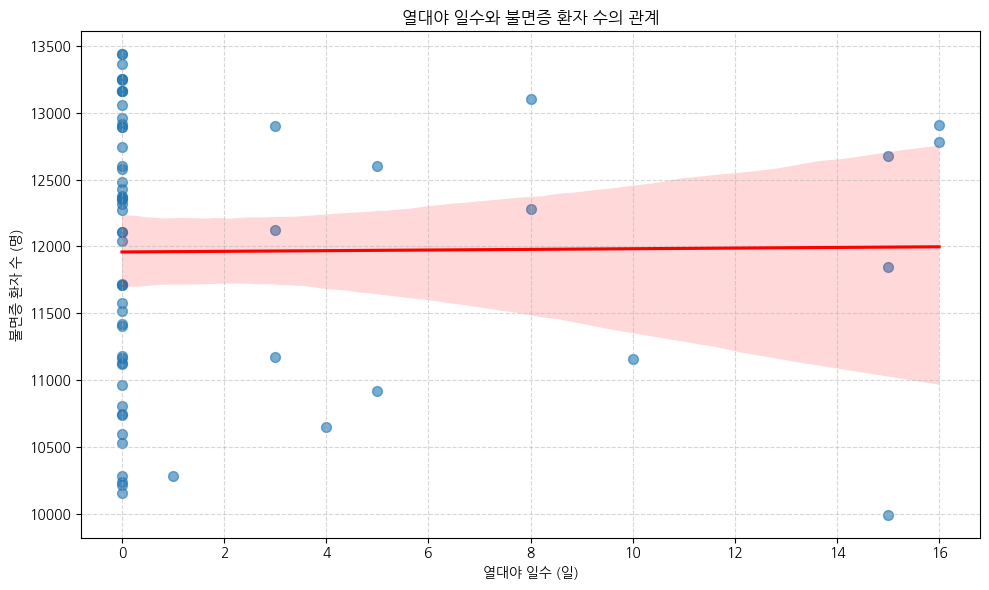

In [49]:
# 상관 그리기
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

#산점도 그리기
sns.regplot(x='대구_열대야일수', y='불면증_환자수', data=df, 
            scatter_kws={'s': 50, 'alpha': 0.6}, line_kws={'color': 'red'})

plt.title('열대야 일수와 불면증 환자 수의 관계')
plt.xlabel('열대야 일수 (일)')
plt.ylabel('불면증 환자 수 (명)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

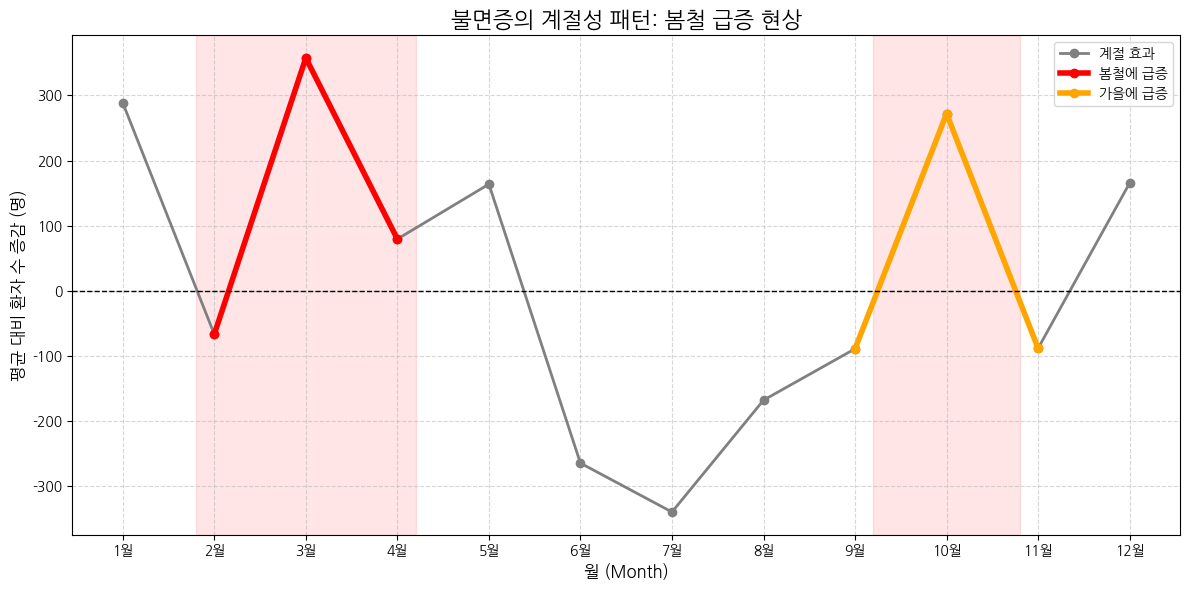

In [63]:

df['Trend'] = df['불면증_환자수'].rolling(window=12, center=True).mean()
# 추세 제거하기
df['Detrended'] = df['불면증_환자수'] - df['Trend']
#월별 패턴
seasonal_pattern = df.groupby(df.index.month)['Detrended'].mean()
plt.figure(figsize=(12, 6))
# 전체 라인 그림
plt.plot(seasonal_pattern.index, seasonal_pattern.values, 
         marker='o', color='gray', linestyle='-', linewidth=2, label='계절 효과')

spring_months = [2, 3, 4]
autumn_months = [9, 10, 11]
plt.plot(spring_months, seasonal_pattern.loc[spring_months], 
         marker='o', color='red', linestyle='-', linewidth=4, label='봄철에 급증')

plt.plot(autumn_months, seasonal_pattern.loc[autumn_months], 
         marker='o', color='orange', linestyle='-', linewidth=4, label='가을에 급증')

plt.axvspan(1.8, 4.2, color='red', alpha=0.1) #배경 강조하기
plt.axvspan(9.2, 10.8, color='red', alpha=0.1) 
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('불면증의 계절성 패턴: 봄철 급증 현상', fontsize=16)
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('평균 대비 환자 수 증감 (명)', fontsize=12)
plt.xticks(range(1, 13), ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

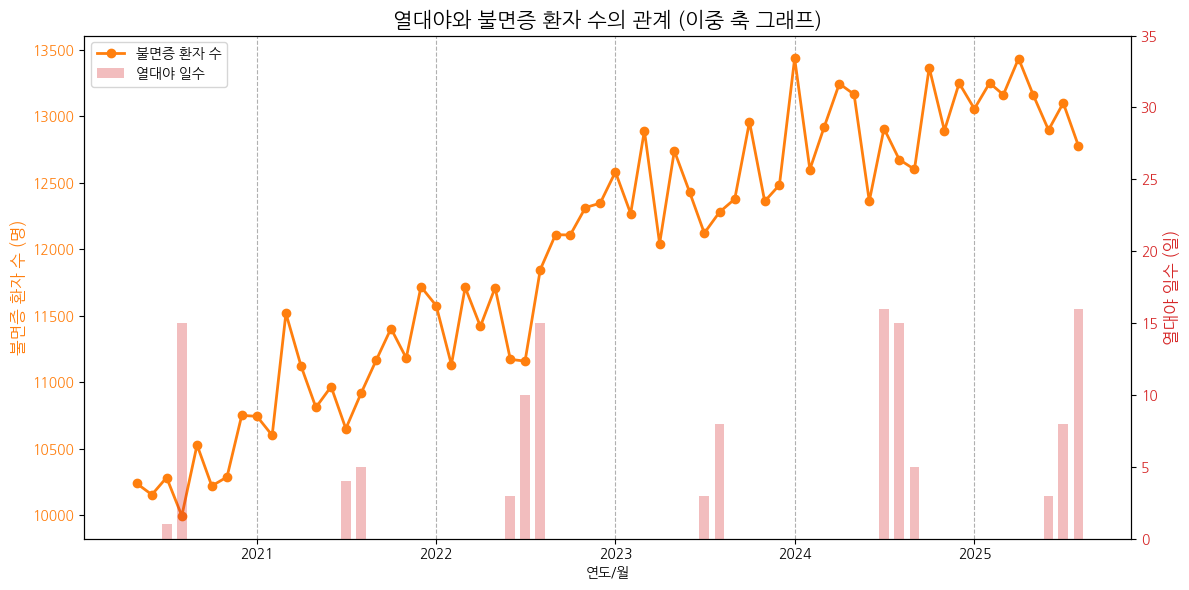

In [58]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 Y축: 불면증 환자 수
color_1 = 'tab:orange'
ax1.set_xlabel('연도/월')
ax1.set_ylabel('불면증 환자 수 (명)', color=color_1, fontsize=12)
ax1.plot(df.index, df['불면증_환자수'], color=color_1, marker='o', linewidth=2, label='불면증 환자 수')
ax1.tick_params(axis='y', labelcolor=color_1)
ax1.grid(True, axis='x', linestyle='--') 

# 오른쪽 Y축: 열대야 일수
# ax1.twinx()를 사용하여 X축을 공유할 수 있음
ax2 = ax1.twinx()
color_2 = 'tab:red'
ax2.set_ylabel('열대야 일수 (일)', color=color_2, fontsize=12)

ax2.bar(df.index, df['대구_열대야일수'], color=color_2, alpha=0.3, width=20, label='열대야 일수')
ax2.tick_params(axis='y', labelcolor=color_2)
ax2.set_ylim(0, 35)

# 제목 설정
plt.title('열대야와 불면증 환자 수의 관계 (이중 축 그래프)', fontsize=15)

lines, labels = ax1.get_legend_handles_labels()
bars, bar_labels = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + bar_labels, loc='upper left')

plt.tight_layout()
plt.show()

열대야와 불면증 간에 상관에 대해서 알아보고자 했다.
모두 여름에 너무 더워서 잠을 편히 주무시지 못한 경험을 해보셨을 것
기온이 올라가면 불면증으로 고생하는 사람이 증가하는지가 궁금증
기온이 증가하면